In [1]:
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
PATH_DATA <- "~/SysBioMed-PLAs/data/datasets/gated_heart_processed.rds"
OUT_DIR <- "../../results/sample_qc/heart"

sample_col <- "donor_id"
celltype_col <- "celltype"
pla_col <- "pla_status"

positive_val <- "PLA"
negative_val <- "platelet-free"

max_ci_width <- 0.30
min_platelet_free <- 20

dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

In [42]:
# dataset <- readRDS(PATH_DATA)
meta <- dataset@meta.data
meta <- meta %>%
  mutate(
    cell_id = rownames(dataset@meta.data),
    sample_id = .data[[sample_col]],
    celltype_id = .data[[celltype_col]],
    pla_status_id = .data[[pla_col]]
  )

In [17]:
wilson_ci <- function(x, n, conf_level = 0.95) {
  z <- qnorm(1 - (1 - conf_level) / 2)
  p <- x / n
  
  denom <- 1 + z^2 / n
  center <- (p + z^2 / (2 * n)) / denom
  half_width <- (z * sqrt((p * (1 - p) / n) + (z^2 / (4 * n^2)))) / denom
  
  lower <- pmax(0, center - half_width)
  upper <- pmin(1, center + half_width)
  
  data.frame(
    ci_lower = lower,
    ci_upper = upper,
    ci_width = upper - lower
  )
}

In [45]:
summary_table <- meta %>%
  filter(!is.na(pla_status_id)) %>%
  group_by(sample_id, celltype_id) %>%
  summarise(
    n_cells = n(),
    n_PLA = sum(pla_status_id == positive_val, na.rm = TRUE),
    n_platelet_free = sum(pla_status_id == negative_val, na.rm = TRUE),
    freq_PLA = n_PLA / n_cells,
    median_nCount_RNA = median(nCount_RNA, na.rm = TRUE),
    median_nCount_ADT = median(nCount_ADT, na.rm = TRUE),
    median_percent_mt = median(percent.mt, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(freq_PLA))

ci_df <- wilson_ci(
  x = summary_table$n_PLA,
  n = summary_table$n_cells
)

summary_table <- bind_cols(summary_table, ci_df)

neg_threshold <- summary_table %>%
  filter(n_platelet_free > 0) %>%
  summarise(threshold = quantile(n_platelet_free, probs = 0.10, na.rm = TRUE)) %>%
  pull(threshold)

neg_threshold <- as.numeric(max(neg_threshold, 20))

summary_table <- summary_table %>%
  mutate(
    enough_precision = ci_width <= max_ci_width,
    enough_negative_control = n_platelet_free >= neg_threshold,
    usable_celltype_sample = enough_precision & enough_negative_control
  ) %>%
  rowwise() %>%
  ungroup()

write.csv(
  summary_table,
  file.path(OUT_DIR, "01_sample_celltype_summary.csv"),
  row.names = FALSE
)


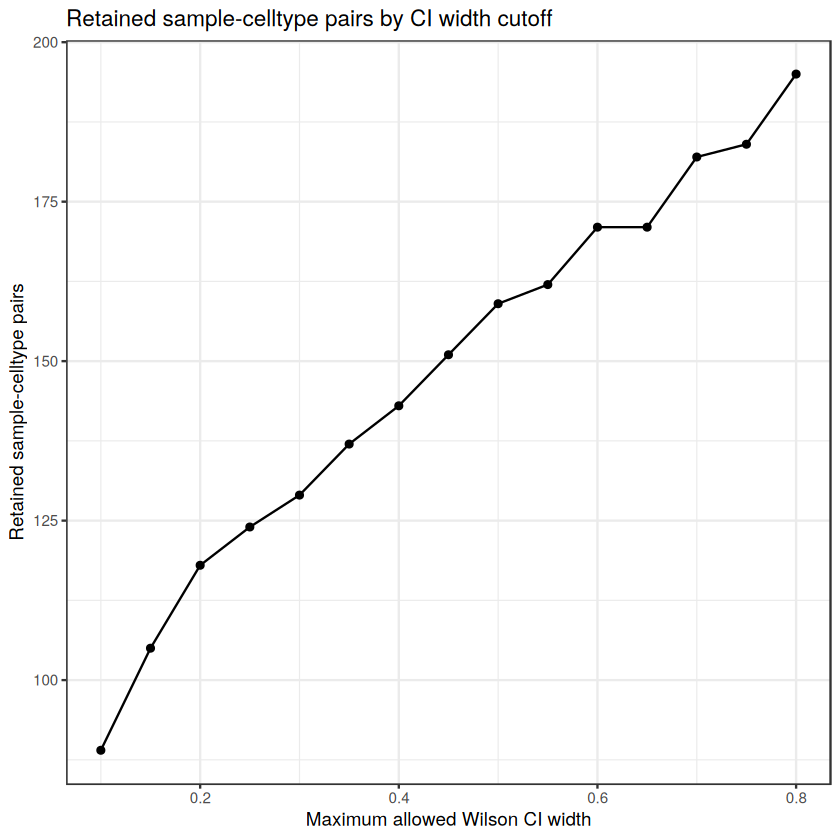

In [64]:
ci_grid <- seq(0.1, 0.8, by = 0.05)

retention_df <- lapply(ci_grid, function(cutoff) {
  tmp <- summary_table %>%
    mutate(usable = ci_width <= cutoff)
  
  data.frame(
    max_ci_width = cutoff,
    retained_pairs = sum(tmp$usable, na.rm = TRUE),
    retained_cells = sum(tmp$n_cells[tmp$usable], na.rm = TRUE),
    retained_PLA = sum(tmp$n_PLA[tmp$usable], na.rm = TRUE)
  )
}) %>%
  bind_rows()

ggplot(retention_df, aes(x = max_ci_width)) +
  geom_line(aes(y = retained_pairs)) +
  geom_point(aes(y = retained_pairs)) +
  theme_bw() +
  labs(
    title = "Retained sample-celltype pairs by CI width cutoff",
    x = "Maximum allowed Wilson CI width",
    y = "Retained sample-celltype pairs"
  )

In [46]:
usable_pairs <- summary_table %>%
  filter(usable_celltype_sample) %>%
  select(sample_id, celltype_id, n_cells, n_PLA, n_platelet_free, freq_PLA, ci_lower, ci_upper, ci_width, enough_negative_control)

excluded_pairs <- summary_table %>%
  filter(!usable_celltype_sample) %>%
  select(sample_id, celltype_id, n_cells, n_PLA, n_platelet_free, freq_PLA, ci_lower, ci_upper, ci_width, enough_negative_control)

write.csv(
  usable_pairs,
  file.path(OUT_DIR, "02_usable_sample_celltype_pairs.csv"),
  row.names = FALSE
)

write.csv(
  excluded_pairs,
  file.path(OUT_DIR, "03_excluded_sample_celltype_pairs.csv"),
  row.names = FALSE
)

In [48]:
plot_df <- summary_table %>%
  mutate(
    sample_id = factor(sample_id, levels = sample_order),
    celltype_id = factor(celltype_id, levels = celltype_order)
  ) %>%
  complete(
    sample_id,
    celltype_id,
    fill = list(
      n_cells = NA_integer_,
      n_PLA = NA_integer_,
      n_platelet_free = NA_integer_,
      freq_PLA = NA_real_,
      ci_width = NA_real_,
      enough_precision = FALSE,
      enough_negative_control = FALSE,
      usable_celltype_sample = FALSE
    )
  ) %>%
  mutate(
    freq_PLA_plot = ifelse(usable_celltype_sample, freq_PLA, NA_real_),
    label_fraction = case_when(
      is.na(n_cells) ~ "NA",
      !enough_precision & !enough_negative_control ~ "unstable\nlow neg",
      !enough_precision ~ "unstable",
      !enough_negative_control ~ "low neg",
      usable_celltype_sample ~ paste0(round(freq_PLA * 100, 1), "%"),
      TRUE ~ ""
    )
  )

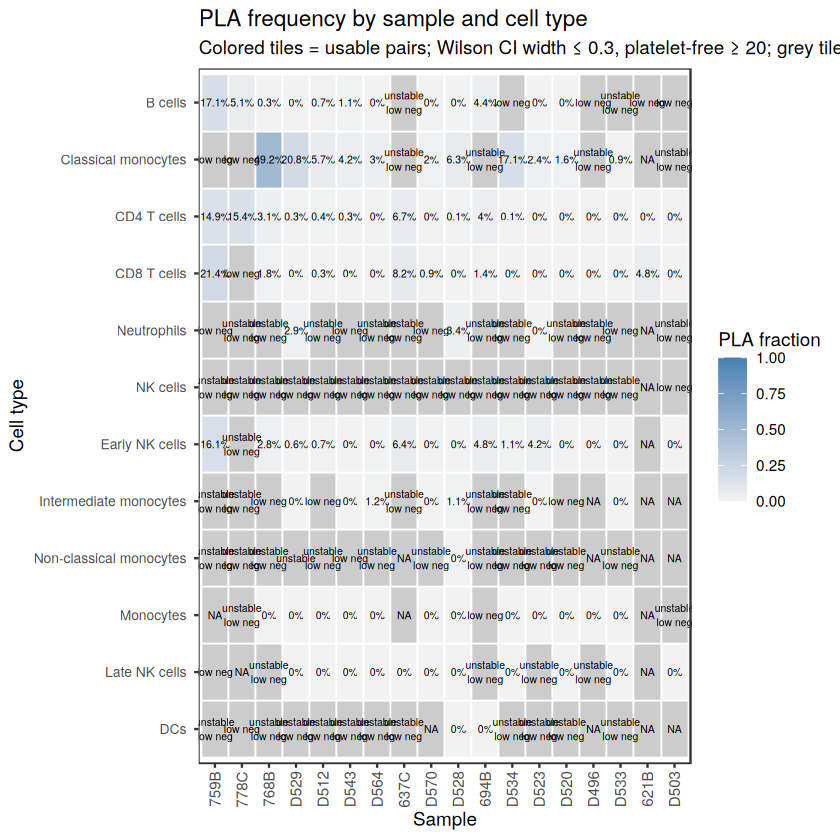

In [50]:
plot_width <- max(10, length(sample_order) * 0.35)
plot_height <- max(7, length(celltype_order) * 0.28)

p_heat <- ggplot(plot_df, aes(x = sample_id, y = celltype_id, fill = freq_PLA_plot)) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = label_fraction), size = 2.1) +
  scale_fill_gradient(
    low = "grey95",
    high = "steelblue",
    limits = c(0, 1),
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.text.y = element_text(size = 8)
  ) +
  labs(
    title = "PLA frequency by sample and cell type",
    subtitle = paste0(
      "Colored tiles = usable pairs; Wilson CI width ≤ ", max_ci_width,
      ", platelet-free ≥ ", neg_threshold,
      "; grey tiles = not present or not usable"
    ),
    x = "Sample",
    y = "Cell type",
    fill = "PLA fraction"
  )

print(p_heat)

ggsave(
  file.path(OUT_DIR, "04_PLA_frequency_by_sample_celltype_filtered.png"),
  p_heat,
  width = plot_width,
  height = plot_height,
  dpi = 300
)

In [59]:
qc_overview <- summary_table %>%
  summarise(
    total_pairs = n(),
    usable_pairs = sum(usable_celltype_sample, na.rm = TRUE),
    unstable_pairs = sum(!enough_precision, na.rm = TRUE),
    low_neg_pairs = sum(!enough_negative_control, na.rm = TRUE),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    total_cells = sum(n_cells, na.rm = TRUE),
    total_PLA = sum(n_PLA, na.rm = TRUE),
    retained_cell_fraction = retained_cells / total_cells,
    retained_PLA_fraction = retained_PLA / total_PLA
  )

print(qc_overview)
write.csv(qc_overview, file.path(OUT_DIR, "05_qc_filter_overview.csv"), row.names = FALSE)

# A tibble: 1 × 10
  total_pairs usable_pairs unstable_pairs low_neg_pairs retained_cells
        <int>        <int>          <int>         <int>          <int>
1         196          110             67            85          48013
# ℹ 5 more variables: retained_PLA <int>, total_cells <int>, total_PLA <int>,
#   retained_cell_fraction <dbl>, retained_PLA_fraction <dbl>


In [60]:
usable_by_celltype <- summary_table %>%
  group_by(celltype_id) %>%
  summarise(
    total_pairs = n(),
    usable_pairs = sum(usable_celltype_sample, na.rm = TRUE),
    usable_samples = n_distinct(sample_id[usable_celltype_sample]),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    mean_freq_PLA_usable = mean(freq_PLA[usable_celltype_sample], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(retained_PLA))

print(usable_by_celltype, n = Inf)
write.csv(usable_by_celltype, file.path(OUT_DIR, "06_usable_by_celltype.csv"), row.names = FALSE)

# A tibble: 12 × 7
   celltype_id            total_pairs usable_pairs usable_samples retained_cells
   <chr>                        <int>        <int>          <int>          <int>
 1 "B cells "                      18           12             12           7328
 2 "CD4 T cells "                  18           18             18          18079
 3 "Classical monocytes "          17           11             11           6912
 4 "CD8 T cells "                  18           17             17           6308
 5 "Early NK cells "               17           16             16           2823
 6 "Intermediate monocyt…          15            7              7            653
 7 "Neutrophils "                  17            3              3            118
 8 "DCs "                          14            2              2            106
 9 "Late NK cells "                16           11             11           1644
10 "Monocytes "                    15           12             12           4008
11 "NK ce

In [62]:
usable_by_sample <- summary_table %>%
  group_by(sample_id) %>%
  summarise(
    total_celltypes = n(),
    usable_celltypes = sum(usable_celltype_sample, na.rm = TRUE),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    mean_freq_PLA_usable = mean(freq_PLA[usable_celltype_sample], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(retained_PLA))

print(usable_by_sample, n = Inf)
write.csv(usable_by_sample, file.path(OUT_DIR, "07_usable_by_sample.csv"), row.names = FALSE)

# A tibble: 18 × 6
   sample_id total_celltypes usable_celltypes retained_cells retained_PLA
   <chr>               <int>            <int>          <int>        <int>
 1 759B                   11                4           6455         1081
 2 768B                   12                6           2699           82
 3 D529                   12                9           3277           74
 4 D543                   12                8           2981           53
 5 D512                   12                7           4548           52
 6 D528                   12               11           3944           36
 7 D570                   11                8           2967           36
 8 D564                   12                8           2148           35
 9 778C                   11                2            510           34
10 637C                   10                4            374           24
11 D534                   12                6           5370           16
12 D523            

In [63]:
usable_pairs <- summary_table %>%
  filter(usable_celltype_sample) %>%
  select(sample_id, celltype_id)

meta_usable <- meta %>%
  semi_join(usable_pairs, by = c("sample_id", "celltype_id"))

usable_cells <- meta_usable$cell_id

dataset_usable <- subset(dataset, cells = usable_cells)

saveRDS(
  dataset_usable,
  file.path(OUT_DIR, "dataset_usable_sample_celltype_pairs.rds")
)